In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

C:\Users\Lena\Promotion\neurolib\GUI\current\gui\data\01120
01120


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 4
limit = 40
i_range = range(0, limit,i_stepsize)
i_range_0 = range(0, limit,i_stepsize)
i_range_1 = range(0, limit,i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003


In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  0 , total integrated cost =  13602.2666253313
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  12 0.47500000000000014 0.4250000000000001

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  1 , total integrated cost =  185.1659945384979
RUN  2 , total integrated cost =  49.6738209340149
RUN  3 , total integrated cost =  48.756146842442206
RUN  4 , total integrated cost =  48.63537645172923
RUN  5 , total integrated cost =  48.4687349563393
RUN  6 , total integrated cost =  48.40506704536778
RUN  7 , total integrated cost =  48.268767164338584
RUN  8 , total integrated cost =  48.17717703981082
RUN  9 , total integrated cost =  47.72662667993171
RUN  10 , total integrated cost =  47.26117864194067
RUN  11 , total integrated cost =  43.24424732598461
RUN  12 , total integrated cost =  40.07054089928706
RUN  13 , total integrated cost =  40.03560931142774
RUN  14 , total integrated cost =  40.00666403558751
RUN  15 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1691 , total integrated cost =  0.8868389858733621
Improved over  1691  iterations in  544.5805442  seconds by  99.99348021171544  percent.
Problem in initial value trasfer:  Vmean_exc -56.676056960040896 -56.676056978537375
weight =  153379.21361154126
set cost params:  1.0 153379.21361154126 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13589.4049455362
Gradient descend method:  None
RUN  1 , total integrated cost =  12653.95014771657
RUN  2 , total integrated cost =  12647.175623388193
RUN  3 , total integrated cost =  12622.508010609708
RUN  4 , total integrated cost =  12612.614702971845
RUN  5 , total integrated cost =  12605.12190829659
RUN  6 , total integrated cost =  12583.108561311425
RUN  7 , total integrated cost =  12577.228261358077
RUN  8 , total integrated cost =  12573.28664321779
RUN  9 , total integrated cost =  12551.489005885516
RUN  10 , total integrated cost =  12545.4607092377
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  28 , total integrated cost =  12381.92338781397
Improved over  28  iterations in  8.86676609999995  seconds by  8.885463068924594  percent.
Problem in initial value trasfer:  Vmean_exc -56.675751707710994 -56.675759752120904
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  41.08020814986787
RUN  2 , total integrated cost =  26.038858710951775
RUN  3 , total integrated cost =  24.13493774396944
RUN  4 , total integrated cost =  23.626353572833693
RUN  5 , total integrated cost =  23.335166831121075
RUN  6 , total integrated cost =  22.560299200118674
RUN  7 , total integrated cost =  22.022542084472764
RUN  8 , total integrated cost =  18.170365841788936
RUN  9 , total integrated cost =  15.133605040470643
RUN  10 , total integrated cost =  14.81034493210166
RUN  

...

RUN  19 , total integrated cost =  15870.544357891647
Control only changes marginally.
RUN  19 , total integrated cost =  15870.544357891647
Improved over  19  iterations in  8.244268200000079  seconds by  4.1086356147482945  percent.
Problem in initial value trasfer:  Vmean_exc -56.68569602425479 -56.68569438201546
-------  36 0.4250000000000001 0.5500000000000003
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7741.667733280556
Gradient descend method:  None
RUN  1 , total integrated cost =  7741.667733280292
RUN  2 , total integrated cost =  7741.667733280272
RUN  3 , total integrated cost =  7741.66773328027
RUN  4 , total integrated cost =  7741.667733280269
RUN  5 , total integrated cost =  7741.667733280267
RUN  6 , total integrated cost =  7741.6677332802665


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  7741.6677332802665
Control only changes marginally.
RUN  7 , total integrated cost =  7741.6677332802665
Improved over  7  iterations in  3.6330723999999464  seconds by  3.723243935382925e-12  percent.
Problem in initial value trasfer:  Vmean_exc -77.76262970216536 -77.76262978402806
weight =  10.000000000000373
set cost params:  1.0 10.000000000000373 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7741.6677332802665
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7741.6677332802665
Control only changes marginally.
RUN  1 , total integrated cost =  7741.6677332802665
Improved over  1  iterations in  0.607256100000086  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -77.76262970216536 -77.76262978402806


--------- 0
--------- 4
--------- 8
--------- 12
--------- 16
--------- 20
--------- 24


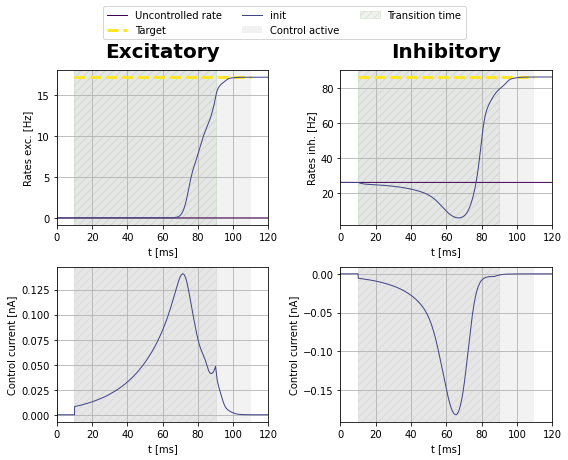

--------- 28
--------- 32
--------- 36


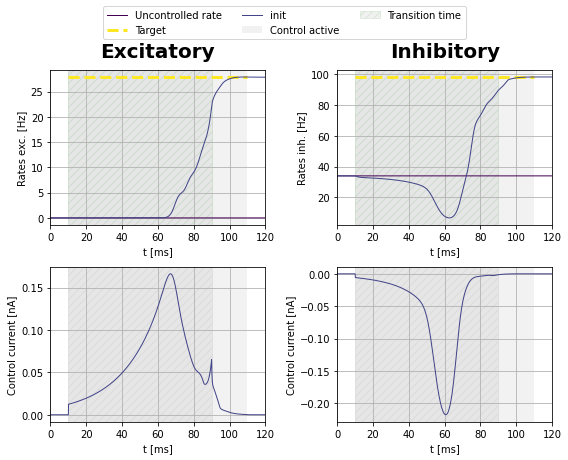

In [55]:

#plot initial guesses
for i in i_range:
    print("---------", i)
    
    if i not in [24,36]:
        continue
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [54]:
found_solution = []
no_solution = []
factor_iteration = 2.
already_tried = [ [] for _ in range(len(exc)) ]
factor_rescale = 1.

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break


    for i in i_range:
        print("------- ", i, exc[i], inh[i])        

        if np.abs(np.mean(bestState_init[i][0,0,-100:]) - target[i][0,0,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - target[i][0,1,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
            bestState_init[i][0,0,:]) < target[i][0,0,-1] + 1. and np.amax(
            bestState_init[i][0,1,:]) < target[i][0,1,-1] + 1.:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        if len(found_solution) == 0:
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        aln.params.duration = dur
            
        if closest_ != -1:
            control0 = aln.getZeroControl()
            control0[:,0,:] = bestControl_init[closest_][:,0,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = factor_rescale * bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
    break

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  4 0.4500000000000001 0.3750000000000001
found solution for  4
-------  8 0.47500000000000014 0.40000000000000013
found solution for  8
-------  12 0.47500000000000014 0.42500000000000016
found solution for  12
-------  16 0.47500000000000014 0.4500000000000002
found solution for  16
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  24 0.4000000000000001 0.5000000000000002
[0, 4, 8, 12, 16, 20] []
closest index  20
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2990.6486014709835
Gradient descend method:  None
RUN  1 , total integrated cost =  241.65819068329725
RUN  2 , total integrated cost =  238.13311824699898
RUN  3 

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  168.82172584449717
RUN  200 , total integrated cost =  168.82172584449717
Improved over  200  iterations in  36.968552900000304  seconds by  94.35501296402859  percent.
Problem in initial value trasfer:  Vmean_exc -56.651889379526104 -56.6518922606686
weight =  176.57571130029748
set cost params:  1.0 176.57571130029748 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2978.8400458729116
Gradient descend method:  None
RUN  1 , total integrated cost =  2974.6833031825427
RUN  2 , total integrated cost =  2969.636823467118
RUN  3 , total integrated cost =  2963.616597328345
RUN  4 , total integrated cost =  2956.710030204692
RUN  5 , total integrated cost =  2949.7793351736213
RUN  6 , total integrated cost =  2944.311575784806
RUN  7 , total integrated cost =  2939.3577987133476
RUN  8 , total integrated cost =  2934.532995235299
RUN  9 , total integrated cost =  2929.3002401222916
RUN  10 , total integrated cost =  2924.4241

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  825 , total integrated cost =  1856.422487494715
Improved over  825  iterations in  188.91944709999962  seconds by  37.67968541759302  percent.
Problem in initial value trasfer:  Vmean_exc -56.65229363337973 -56.6522930160943
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  32 0.47500000000000014 0.5250000000000002
found solution for  32
-------  36 0.4250000000000001 0.5500000000000003
[0, 4, 8, 12, 16, 20, 28, 32] []
closest index  32
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2048.6544894480558
Gradient descend method:  None
RUN  1 , total integrated cost =  700.453237399539
RUN  2 , total integrated cost =  510.5121885995235
RUN  3 , total integrated cost =  450.2976150271654
RUN  4 , total integrated cost =  424.97591701938967
RUN  5 , total integrated cost =  408.90576873597354
RUN  6 , total integrated cost =  397.06478030308887

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  141.51875973595037
RUN  200 , total integrated cost =  141.51875973595037
Improved over  200  iterations in  35.41672210000024  seconds by  93.09211189759587  percent.
Problem in initial value trasfer:  Vmean_exc -56.636292428965945 -56.63628689484347
weight =  547.0418019296646
set cost params:  1.0 547.0418019296646 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7724.536982334913
Gradient descend method:  None
RUN  1 , total integrated cost =  7690.0093654759285
RUN  2 , total integrated cost =  7593.512125427969
RUN  3 , total integrated cost =  7521.332562078519
RUN  4 , total integrated cost =  7513.457023238898
RUN  5 , total integrated cost =  7507.331870159633
RUN  6 , total integrated cost =  7505.452950111054
RUN  7 , total integrated cost =  7499.107444265104
RUN  8 , total integrated cost =  7497.827343713749
RUN  9 , total integrated cost =  7496.044293949301
RUN  10 , total integrated cost =  7494.3571072804

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  112 , total integrated cost =  7379.863082262554
Improved over  112  iterations in  38.925814100000025  seconds by  4.462065504516161  percent.
Problem in initial value trasfer:  Vmean_exc -56.636317961617564 -56.63631119972656


In [56]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print("------------------------------------------------")
    print('-------------------------', counter)
    
    if counter > 20:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_init[i] == [True, True]:
            continue
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
                       
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
    counter += 1

------------------------------------------------
------------------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  18445.854447083333
set cost params:  1.0 18445.854447083333 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  463594.7334573981
Gradient descend method:  None
RUN  1 , total integrated cost =  6073.615419966853
RUN  2 , total integrated cost =  5896.438211152963
RUN  3 , total integrated cost =  58

ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  5896.025568073109
Control only changes marginally.
RUN  7 , total integrated cost =  5896.025568073109
Improved over  7  iterations in  3.12727649999988  seconds by  98.72819401460804  percent.
Problem in initial value trasfer:  Vmean_exc -62.90351706496191 -62.90458113076869
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  168719.45655208407
set cost params:  1.0 168719.45655208407 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  104635.4820372462
Gradient descend method:  None
RUN  1 , total integrated cost =  13721.008946534837
RUN  2 , total integrated cost =  13595.83909500222
RUN  3 , total integrated cost =  13595.707446025424
RUN  4 , total integrated cost =  13595.707283683394
RUN  5 , total integrated cost =  13595.70728368339
RUN  6 , total integrated cost =  13595.707283683389


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  13595.707283683389
Control only changes marginally.
RUN  7 , total integrated cost =  13595.707283683389
Improved over  7  iterations in  3.115501000000222  seconds by  87.0065994641819  percent.
Problem in initial value trasfer:  Vmean_exc -61.63222448309185 -61.63255126249076
converged for  4
-------  8 0.47500000000000014 0.40000000000000013
weight =  348120.54042883904
set cost params:  1.0 348120.54042883904 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  161576.10734712495
Gradient descend method:  None
RUN  1 , total integrated cost =  17554.07705603523
RUN  2 , total integrated cost =  17547.6717839558
RUN  3 , total integrated cost =  17547.66625784569
RUN  4 , total integrated cost =  17547.66625650098
RUN  5 , total integrated cost =  17547.66625650008
RUN  6 , total integrated cost =  17547.666256500073


...

RUN  4 , total integrated cost =  5896.143236604033
Control only changes marginally.
RUN  4 , total integrated cost =  5896.143236604033
Improved over  4  iterations in  2.621257799999512  seconds by  1.7695853671284567e-08  percent.
Problem in initial value trasfer:  Vmean_exc -62.90396939074063 -62.90502858305996
no convergence
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
weight =  48132.7633092653
set cost params:  1.0 48132.7633092653 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17570.364627688614
Gradient descend method:  None
RUN  1 , total integrated cost =  17570.364627687806


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  17570.364627687806
Control only changes marginally.
RUN  2 , total integrated cost =  17570.364627687806
Improved over  2  iterations in  1.257792899999913  seconds by  4.590106073010247e-12  percent.
Problem in initial value trasfer:  Vmean_exc -63.93807978131163 -63.93820642497022
no convergence
-------  16 0.47500000000000014 0.4500000000000002
weight =  15427.513767315299
set cost params:  1.0 15427.513767315299 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17340.84831495187
Gradient descend method:  None
RUN  1 , total integrated cost =  17340.848314951352
RUN  2 , total integrated cost =  17340.84831495134


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  17340.84831495134
Control only changes marginally.
RUN  3 , total integrated cost =  17340.84831495134
Improved over  3  iterations in  1.3983302000006006  seconds by  3.0411229090532288e-12  percent.
Problem in initial value trasfer:  Vmean_exc -66.34619307527277 -66.3462273379836
no convergence
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
------------------------------------------------
------------------------- 21


In [57]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [58]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  18445.854447083333
set cost params:  1.0 18445.854447083333 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.086511056482
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5902.086511056482
Control only changes marginally.
RUN  1 , total integrated cost =  5902.086511056482
Improved over  1  iterations in  0.8782249999994747  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62664844532568 -56.62665497872078
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  169041.09445426395
set cost params:  1.0 169041.09445426395 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13595.717703323442
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13595.717703323442
Control only changes marginally.
RUN  1 , total integrated cost =  13595.717703323442
Improved over  1  iterations in  0.892903999999362  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -61.63222448309185 -61.63255126249076
converged for  4
-------  8 0.47500000000000014 0.40000000000000013
weight =  348324.75156943226
set cost params:  1.0 348324.75156943226 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17547.668132696108
Gradient descend method:  None


...

RUN  3 , total integrated cost =  17340.848263715685
Control only changes marginally.
RUN  3 , total integrated cost =  17340.848263715685
Improved over  3  iterations in  1.5311031000001094  seconds by  3.694822225952521e-12  percent.
Problem in initial value trasfer:  Vmean_exc -66.34619529837698 -66.34622954931805
no convergence
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
--------------- 20
[[True, True], [True, True], [True, True], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True],

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  17570.36524199509
Control only changes marginally.
RUN  3 , total integrated cost =  17570.36524199509
Improved over  3  iterations in  1.4147150999997393  seconds by  4.234834705130197e-12  percent.
Problem in initial value trasfer:  Vmean_exc -63.938092880522554 -63.93821945192972
no convergence
-------  16 0.47500000000000014 0.4500000000000002
weight =  15407.441094667236
set cost params:  1.0 15407.441094667236 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17340.84826115569
Gradient descend method:  None
RUN  1 , total integrated cost =  17340.848261155046


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  17340.848261155046
Control only changes marginally.
RUN  2 , total integrated cost =  17340.848261155046
Improved over  2  iterations in  1.4816436000000976  seconds by  3.709033080667723e-12  percent.
Problem in initial value trasfer:  Vmean_exc -66.34619541739006 -66.34622966768244
no convergence
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
--------------- 21


In [59]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [60]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [61]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3333982504712099
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3333982504712099
Control only changes marginally.
RUN  1 , total integrated cost =  0.3333982504712099
Improved over  1  iterations in  0.6452737999998135  seconds by  0.0  percent.
converged for  0
-------

ERROR:root:Problem in initial value trasfer


RUN  10000 , total integrated cost =  0.08934656255839088
RUN  10000 , total integrated cost =  0.08934656255839088
Improved over  10000  iterations in  1904.6098911  seconds by  99.99934256825239  percent.
Problem in initial value trasfer:  Vmean_exc -56.67605685137379 -56.67605681996098
no convergence
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17544.46789768754
Gradient descend method:  None
RUN  1 , total integrated cost =  19.05366305230377
RUN  2 , total integrated cost =  4.669958012564684
RUN  3 , total integrated cost =  2.2589141349500435
RUN  4 , total integrated cost =  1.1713732711577312
RUN  5 , total integrated cost =  1.060166660044518
RUN  6 , total integrated cost =  1.0199710325930003
RUN  7 , total integrated cost =  0.9946062241450967
RUN  8 , total integrated cost =  0.9679749351011585
RUN  9 , total integrated cost =  0.9461391655061422
RUN  10 , total int

RUN  11 , total integrated cost =  5.073574922451271
RUN  12 , total integrated cost =  5.047800930421873
RUN  13 , total integrated cost =  5.022614641255017
RUN  14 , total integrated cost =  4.982962438751519
RUN  15 , total integrated cost =  4.939341245670076
RUN  16 , total integrated cost =  4.881419547950637
RUN  17 , total integrated cost =  4.826144319326072
RUN  18 , total integrated cost =  4.817478116010524
RUN  19 , total integrated cost =  4.8092824099108435
RUN  20 , total integrated cost =  4.80388631411914
RUN  30 , total integrated cost =  4.522706830778803
RUN  40 , total integrated cost =  3.5608686951747717
RUN  50 , total integrated cost =  3.0704833113933616
RUN  60 , total integrated cost =  2.5332910074223176
RUN  70 , total integrated cost =  2.351845322427748
RUN  80 , total integrated cost =  2.2184092750145963
RUN  90 , total integrated cost =  2.105369336942592
RUN  100 , total integrated cost =  2.059176427778706
RUN  110 , total integrated cost =  1.997

ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  6.082470140074949
Control only changes marginally.
RUN  1 , total integrated cost =  6.082470140074949
Improved over  1  iterations in  0.5856791000005614  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.685695901941365 -56.68569586021116
converged for  32
-------  36 0.4250000000000001 0.5500000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.55142472203774
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13.55142472203774
Control only changes marginally.
RUN  1 , total integrated cost =  13.55142472203774
Improved over  1  iterations in  0.5695214999996097  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.63611816462909 -56.63611815172129
converged for  36
--------------- 3
[[True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoi

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.08875388457308764
Control only changes marginally.
RUN  1 , total integrated cost =  0.08875388457308764
Improved over  1  iterations in  0.5292145999992499  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67605688036803 -56.67605685042226
converged for  4
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
--------------- 4
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [Tru

----------- 0
111
sart
111
sart
111
sart


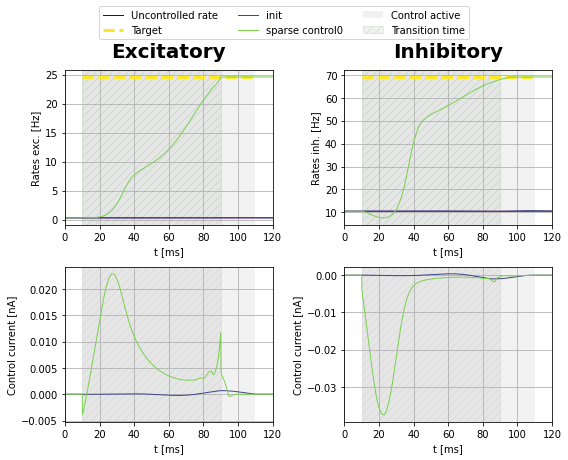

----------- 4
111
sart
111
sart
111
sart


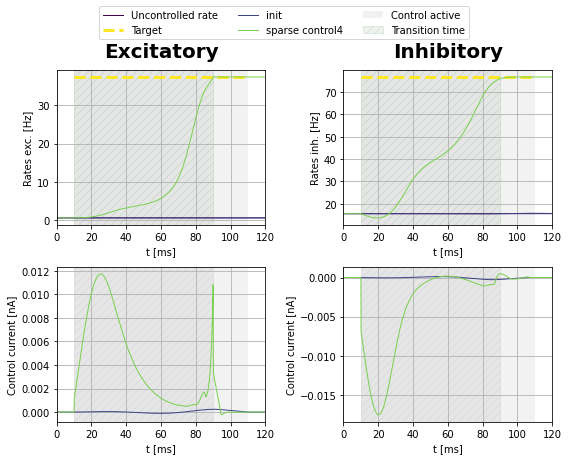

----------- 8
111
sart
111
sart
111
sart


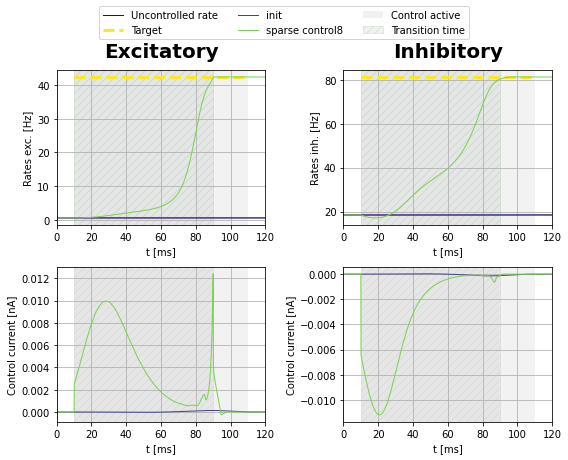

----------- 12
111
sart
111
sart
111
sart


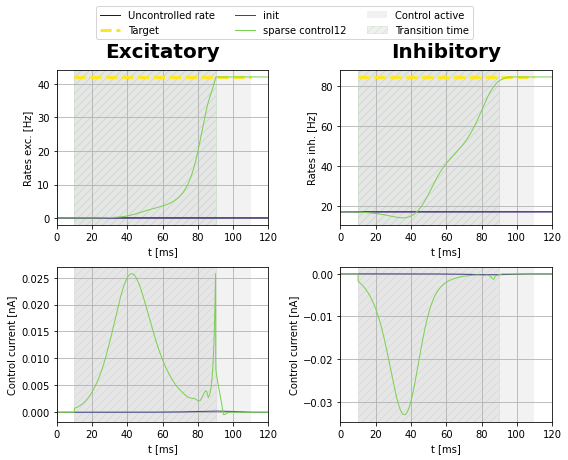

----------- 16
111
sart
111
sart
111
sart


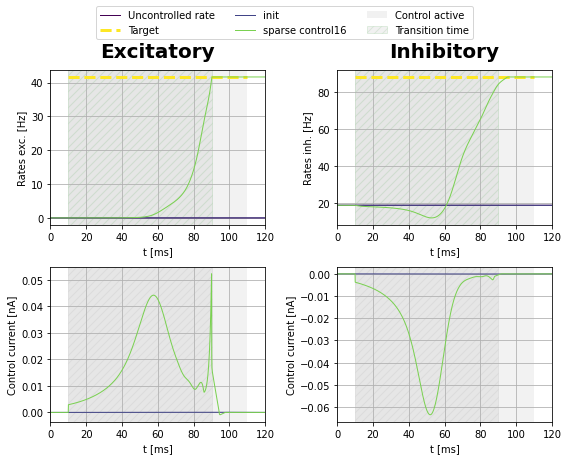

----------- 20
111
sart
111
sart
111
sart


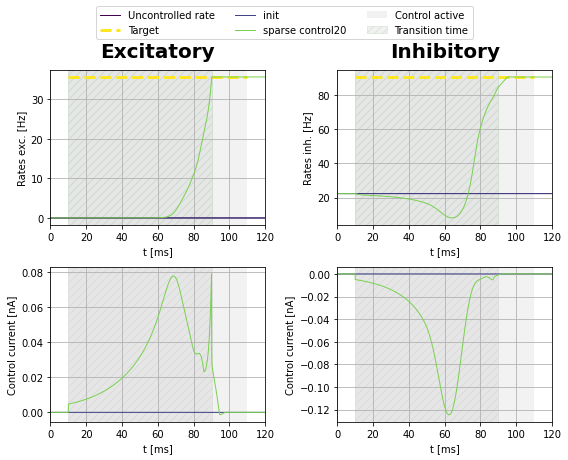

----------- 24
111
sart
111
sart
111
sart


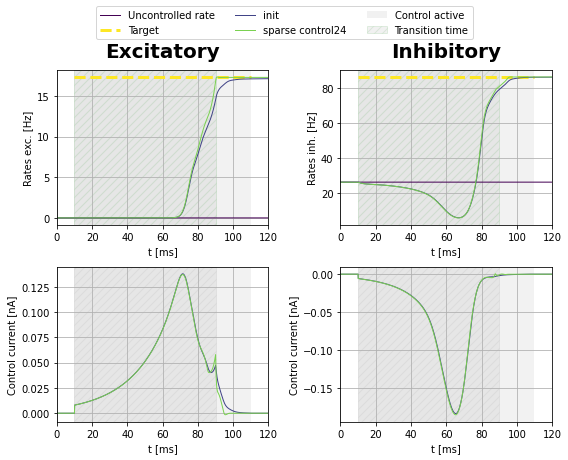

----------- 28
111
sart
111
sart
111
sart


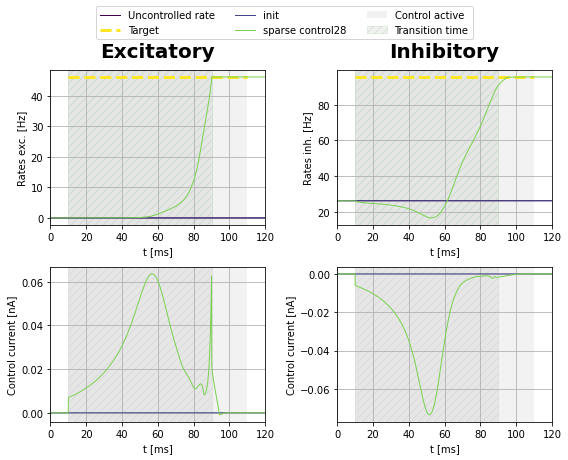

----------- 32
111
sart
111
sart
111
sart


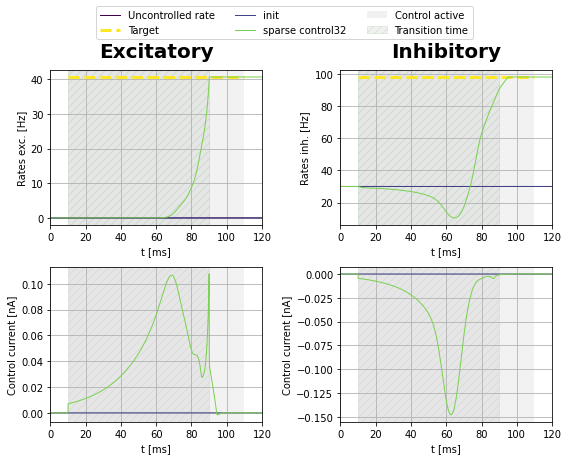

----------- 36
111
sart
111
sart
111
sart


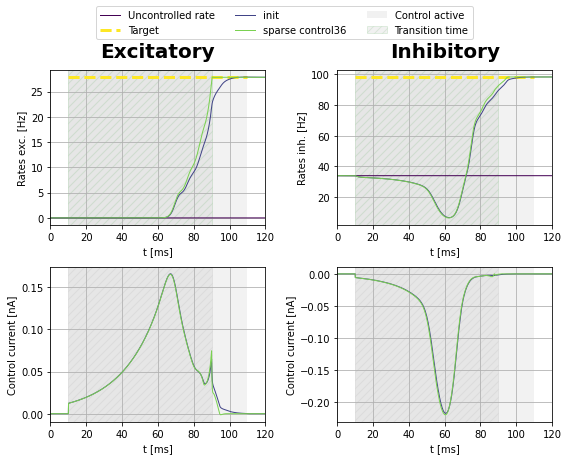

In [62]:
for i in i_range_1:
    
    print('-----------', i)
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_1[i]],
        [costnode_init[i], costnode_1[i]], [weights_init[i], weights_1[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()